# Benchamark

Benchmark de Modelos Base

En esta etapa se construye un **benchmark inicial de modelos de clasificación** sobre el dataset de diabetes, antes de aplicar técnicas de balanceo o de optimización computacional. El objetivo es **evaluar el desempeño predictivo base** de diversos algoritmos y establecer una línea de comparación para las etapas posteriores.

---

### Decisiones del Proceso

1. **Preprocesamiento con `ColumnTransformer`:**  
   - Se diferenciaron las variables **numéricas** y **categóricas** para aplicar transformaciones específicas.  
   - A las variables numéricas se les imputaron valores faltantes con la **mediana** y se escalaron con `StandardScaler`.  
   - A las variables categóricas se les aplicó imputación con la **moda** y luego codificación **One-Hot Encoding**, usando `handle_unknown='ignore'` para evitar errores con categorías nuevas.

2. **División del conjunto de datos:**  
   Se separaron los datos en **80% entrenamiento** y **20% prueba**, estratificando por la variable objetivo para mantener la proporción de clases (desbalance cercano al 54%-46%).

3. **Modelos incluidos:**  
   Se entrenaron diez modelos representativos de distintas familias de algoritmos:
   - Métodos basados en distancia: **KNN**
   - Probabilísticos: **Naive Bayes**
   - Modelos lineales: **Regresión Logística (L1 y L2)**, **Ridge**, **Lasso (SGD)**
   - Árboles de decisión y ensamblados: **Decision Tree**, **Random Forest**, **XGBoost**
   - Máquinas de vectores soporte: **SVM lineal**
   
   Todos los modelos fueron integrados dentro de un `Pipeline` para asegurar un flujo reproducible de preprocesamiento y entrenamiento.

4. **Métricas de evaluación:**  
   Se midieron **Accuracy**, **F1-score** (para capturar el balance entre precisión y exhaustividad) y **AUC** (para evaluar la capacidad discriminante).  
   También se registró el **tiempo de entrenamiento (en segundos)** para posteriores comparaciones de eficiencia computacional.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [ ]:
# ========================
# 1. Carga de librerías
# ========================


# ========================
# 2. Cargar dataset
# ========================
df = pd.read_csv('data/raw/diabetic_data.csv')

# ========================
# 3. Crear variable objetivo binaria ('target')
# Será 1 si el paciente fue reingresado ('<30' o '>30'), y 0 si no ('NO')
# ========================
df['target'] = df['readmitted'].isin(['<30', '>30']).astype(int)
df.drop(columns=['readmitted'], inplace=True)

# ========================
# 4. Eliminar columnas irrelevantes
# ========================
cols_to_drop = [
    "encounter_id", "patient_nbr", "weight", "payer_code", "medical_specialty"
]
df = df.drop(columns=cols_to_drop)
df = df.sample(frac=0.7, random_state=42)

# ========================
# 5. Separar variables predictoras y target
# ========================
X = df.drop(columns=["target"])
y = df["target"]

# ========================
# 6. Identificar tipos de variables
# ========================
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# ========================
# 7. Crear transformadores
# ========================
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ========================
# 8. Combinar en un ColumnTransformer
# ========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ])

# ========================
# 9. Dividir en train y test
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño del train:", X_train.shape)
print("Tamaño del test:", X_test.shape)
print("\nDistribución de la variable objetivo (desbalance):")
print(y.value_counts(normalize=True))

Tamaño del train: (56988, 44)
Tamaño del test: (14248, 44)

Distribución de la variable objetivo (desbalance):
target
0    0.53845
1    0.46155
Name: proportion, dtype: float64


In [ ]:
# =========================================
# 10. Carga de modelos
# =========================================


# =========================================
# 11. Definir modelos benchmark
# =========================================
modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Reg. Logística (L2)": LogisticRegression(penalty="l2", max_iter=1000, n_jobs=-1),
    "Reg. Logística (L1)": LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000),
    "Ridge": RidgeClassifier(),
    "Lasso": SGDClassifier(loss="log_loss", penalty="l1", max_iter=1000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False),
    "SVM (Lineal)": LinearSVC(random_state=42, max_iter=5000)
}

# =========================================
# 12. Entrenamiento y evaluación comparativa
# =========================================
resultados = []

for nombre, modelo in modelos.items():
    print(f"\nEntrenando modelo: {nombre}")
    
    # Pipeline: preprocesamiento + modelo
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", modelo)
    ])
    
    # Tiempo de entrenamiento
    inicio = time.time()
    clf.fit(X_train, y_train)
    fin = time.time()
    tiempo = fin - inicio

    # Predicciones
    y_pred = clf.predict(X_test)

    # Algunos modelos no tienen predict_proba
    if hasattr(clf.named_steps["classifier"], "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf.named_steps["classifier"], "decision_function"):
        y_proba = clf.decision_function(X_test)
    else:
        y_proba = None

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    resultados.append({
        "Modelo": nombre,
        "Accuracy": round(acc, 3),
        "F1-score": round(f1, 3),
        "AUC": round(auc, 3) if not np.isnan(auc) else "N/A",
        "Tiempo (s)": round(tiempo, 2)
    })

# =========================================
# 13. Tabla comparativa
# =========================================
resultados_df = pd.DataFrame(resultados).sort_values(by="F1-score", ascending=False)
print("\n===== RESULTADOS BENCHMARK =====")
display(resultados_df)




Entrenando modelo: KNN

Entrenando modelo: Naive Bayes

Entrenando modelo: Reg. Logística (L2)

Entrenando modelo: Reg. Logística (L1)

Entrenando modelo: Ridge

Entrenando modelo: Lasso

Entrenando modelo: Árbol de Decisión

Entrenando modelo: Random Forest

Entrenando modelo: XGBoost


c:\Users\camil\anaconda3\envs\ML_VENV\lib\site-packages\xgboost\core.py:158: UserWarning: [17:57:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Entrenando modelo: SVM (Lineal)

===== RESULTADOS BENCHMARK =====


,Modelo,Accuracy,F1-score,AUC,Tiempo (s)
1,Naive Bayes,0.481,0.630,0.515,4.94
8,XGBoost,0.646,0.592,0.700,8.69
7,Random Forest,0.637,0.567,0.688,77.50
2,Reg. Logística (L2),0.627,0.548,0.669,67.67
9,SVM (Lineal),0.623,0.546,0.663,16.60
3,Reg. Logística (L1),0.628,0.546,0.672,10.71
4,Ridge,0.623,0.545,0.662,7.87
6,Árbol de Decisión,0.573,0.534,0.570,19.17
0,KNN,0.581,0.529,0.610,2.81
5,Lasso,0.615,0.465,0.665,9.44


## Análisis e Interpretación

- **XGBoost** y **Random Forest** destacan por su **mayor capacidad predictiva (AUC ≈ 0.70)**, evidenciando su fortaleza para capturar relaciones no lineales y combinaciones de variables. Sin embargo, presentan **costos computacionales elevados**, especialmente el Random Forest.

- **Naive Bayes**, aunque simple y con baja precisión global (Accuracy = 0.48), logra el **F1-score más alto (0.63)**. Esto sugiere que es **efectivo en la detección de la clase minoritaria**, lo cual puede ser relevante en contextos médicos donde el *recall* o la detección de casos positivos es prioritaria.

- Los modelos **lineales** (Regresión Logística, Ridge, Lasso, SVM) ofrecen un **buen equilibrio entre interpretabilidad, tiempo y desempeño**, con AUC entre 0.66 y 0.67. Estos modelos son útiles como referencia base para comparaciones posteriores con técnicas de regularización o balanceo.

- **KNN** logra un desempeño moderado con **bajo costo computacional**, lo cual lo hace atractivo para entornos donde se prioriza la velocidad sobre la exactitud.

- El **Árbol de Decisión simple** obtiene resultados más bajos, lo que confirma la necesidad de ensamblados como *Random Forest* o *Boosting* para mejorar su rendimiento.

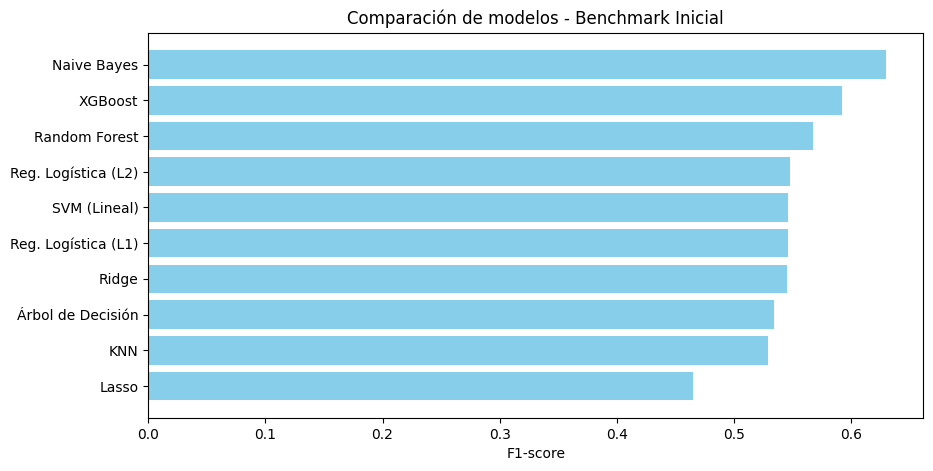

In [ ]:


plt.figure(figsize=(10, 5))
plt.barh(resultados_df["Modelo"], resultados_df["F1-score"], color='skyblue')
plt.xlabel("F1-score")
plt.title("Comparación de modelos - Benchmark Inicial")
plt.gca().invert_yaxis()
plt.show()

### Conclusión

Los resultados del benchmark inicial muestran que, sin técnicas de balanceo ni optimización, los modelos basados en árboles (especialmente XGBoost) logran el mejor desempeño general. No obstante, su mayor tiempo de cómputo y posible sobreajuste invitan a explorar las **técnicas de balanceo de clases y optimización computacional** en las siguientes fases del proyecto, con el fin de mejorar tanto la eficiencia como la equidad en la detección de casos positivos.